In [2]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)



In [ ]:
#Quench Functions
#These must be in the form (t, args) to work! 
def g_linear_hold(t,args):
    tau,tf= args
    if t<tf:
        return 1-t/tau
    else:
        return 1-tf/tau+(t-tf)/tau
def g_pulse(t,args):
    t0,tf = args
    if t> t0 and t<tf:
        return 1
    else:
        return 0
def g_exp_slowdown(t,args):
    A,B,C = args
    return A+B*exp(-t*C)

def sin_g(t,args):
    A,B,C = args
    return  A+B*sin(C*t)


#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
###

def BdG_evolve(t,U,g,q,args):
    return -1j*BdG(q,g(t,args))@U
def groundstate(g,L):
    n = np.arange(0, L//2 )
    k = (2 * n + 1) * pi / L
    us,vs=[],[]
    for ki in k:
        V0 = la.eigh(BdG(ki, g))[1][:, 1]
        us.append(V0[0])
        vs.append(V0[1])
    us,vs = array(us),array(vs)
    return [us,vs,k]


def evolve_mode(q,g,t_eval,u0,v0,args):
    V0 = array([u0,v0])
    sol = solve_ivp(
        BdG_evolve,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(g,q,args),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(L,t_eval,g,args):
    g0 = g(t_eval[0],args)
    print(g0)
    u,v,k = groundstate(g0,L)
    
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(k[i], g, t_eval,u[i],v[i],args) for i in range(len(k))
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states

def overlap(states,state):
    overlaps = []
    u0,v0,_ = state
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)


0.0


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


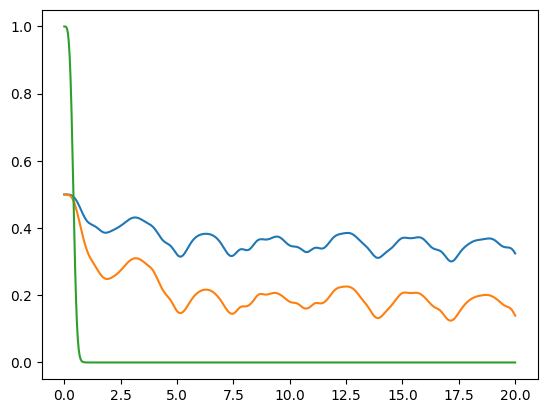

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Numerical Quenches/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


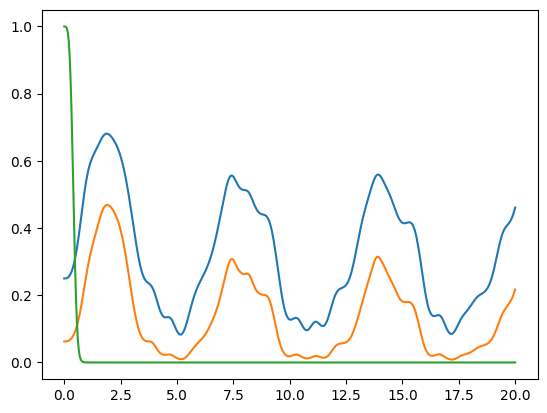

In [151]:
tau = 1
L = 100
t_eval = np.linspace(0,20*tau,500)
args = [-tau/4,tau/4]
args=[1.1,1/1]
states= landau_states(L,t_eval,sin_g,args)

xx = [(kz.P_n(2,s)) for s in states]

plot(t_eval/tau,xx)

xx = [(kz.P_n(4,s)) for s in states]

plot(t_eval/tau,xx)
plot(t_eval/tau,(overlap(states,groundstate(0,L))))
show()

xx = [(zz.P_n(2,s)) for s in states]

plot(t_eval/tau,xx)

xx = [(zz.P_n(4,s)) for s in states]

plot(t_eval/tau,xx)
plot(t_eval/tau,(overlap(states,groundstate(0,L))))
show()

#yscale("log")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


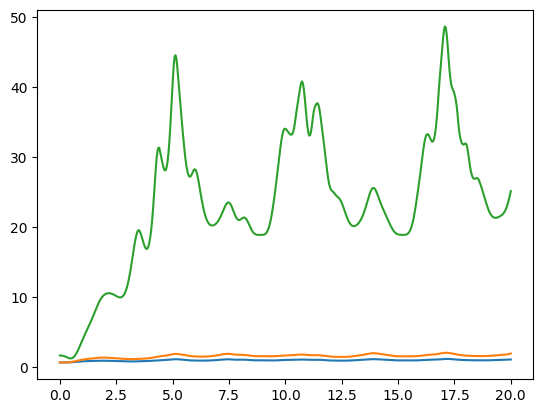

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Numerical Quenches/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


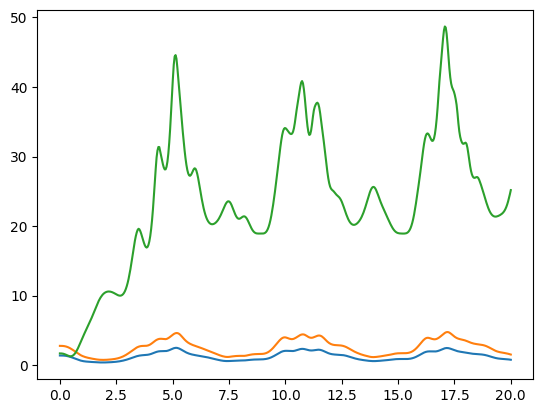

In [152]:

xx = [-log(kz.P_n(2,s)) for s in states]

plot(t_eval/tau,xx)

xx = [-log(kz.P_n(4,s)) for s in states]

plot(t_eval/tau,xx)
plot(t_eval/tau,-log(overlap(states,groundstate(.5,L))))
show()
#yscale("log")

xx = [-log(zz.P_n(2,s)) for s in states]

plot(t_eval/tau,xx)

xx = [-log(zz.P_n(4,s)) for s in states]

plot(t_eval/tau,xx)
plot(t_eval/tau,-log(overlap(states,groundstate(.5,L))))
show()
#yscale("log")